# Sankey (gráfico de flujo o trasvase de información) para votaciones

## Realizado por Antonio Carrillo Sánchez, alumno máster UCM mayo 2024

Con su permiso, que muy amablemente me concedió, creo interesante compartir con otros módulos de visualización del máster UCM este extraordinario trabajo que muestra la enorme utilidad de este tipo de gráficos para mostrar evolución, transferencia, o flujo de información

## 0. Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
from scipy.interpolate import make_interp_spline

### 1. Presentación y codificación de datos

Los datos que se van a utilizar en este ejercicio de visualización son los que facilita el CIS en su web (www.cis.es/es/detalle-ficha-estudio?idEstudio=14752), resultado del barómetro de septiembre del pasado año. Dicho barómetro corresponde a la encuesta postelectoral de las elecciones generales de julio del 2023.

El CIS facilita el dataset con las respuestas de la encuesta y el dataset ya codificado. Se van a utilizar el dataset de los datos códificados en primer lugar porque el nombre de las columnas viene códificado y no es la pregunta de la encuesta del barómetro y en segundo lugar, con la idea de llevar transformaciones (si fuesen necesarias) de forma más rápida, en caso de necesitar nombrar las categorías para una visualización se explicará dicha codificación extraida del libro de códigos facilitado también por el organismo público.

In [2]:
df = pd.read_csv('3420_num.csv', sep=';')
print(df.shape)
df.head(5)

(10101, 232)


,ESTUDIO,REGISTRO,CUES,PROV,MUN,CCAA,CAPITAL,ENTREV,TAMUNI,TIPO_TEL,...,INTENCIONGR,INTENCIONGALTERR,VOTOSIMG,RECUVOTOGR,RECUERDO,ESTUDIOS,CNO11R,CLASESUB,PESO,PESOCCAA
0,3420,46,1,47,186,8,1,0,5,2,...,1,2,1,0,9995,3,7,4,"1,41998","0,93107"
1,3420,188,2,11,0,1,3,0,3,1,...,2,9993,2,2,2,6,12,2,"1,03851","1,01261"
2,3420,200,3,26,89,17,1,0,5,1,...,2,9997,2,2,2,6,14,9,"0,24212","0,70314"
3,3420,229,4,51,1,18,1,0,4,2,...,2,9993,2,1,1,6,4,2,"0,34879","1,084"
4,3420,239,5,10,37,11,2,0,4,2,...,2,9997,2,2,2,6,1,2,"0,72528","0,73783"


Como vemos el conjunto de datos tiene un total de 232 columnas y 10101 observaciones. Vamos a reducir el tamañan del dataframe escogiendo aquellas columnas que se vayan a utilizar para las visualizaciones del ejercicio. Se van a seleccionar columnas (un total de 7) relacionadas con el perfil político del encuestado y variables de ideología y voto (2019 y 2023).

In [3]:
columnas = ['PROV', 'SEXO', 'EDAD',
            'RECUERDO1R', 'ESCIDEOL',
            'RECUVOTOGR', 'NIVELESTENTREV']

df = df[columnas]

print(df.shape)

(10101, 7)


Antes de comenzar con las visualizaciones, se creará un diccionario con los colores distintivos (en el caso de EH Bildu se ha optado por el verde más oscuro de su logo ya que el verde claro o el azul corporativo podían confundirse en las visualizaciones con los colores de Vox y Junts respectivamente) de cada uno de los partidos políticos más votados en las últimas elecciones y partidos de segundo orden que podrían salir en las próximas visualizaciones.

In [4]:
color_partidos = {
    'PSOE': '#e4040c',
    'PP': '#0554a3',
    'VOX': '#5cc434',
    'Sumar': '#e40c54 ',
    'Junts': '#04c4b4',
    'ERC': '#fbb31b ',
    'EAJ-PNV': '#048344 ',
    'EH Bildu': '#aabe0f',
    'Otros partidos': 'grey',
    'Ciudadanos': '#fc4c04',
    'JxCat': '#c60f53',
    'Unidas Podemos':  '#7b2c64',
    'Más País':  '#044130' ,
    'N.P.': 'yellow',
    'No votó': 'yellow'
}

Seguidamente se van a llevar a cabo varias transformaciones en dos variables muy importantes de este conjunto de datos que van a ser utilizadas a posteriori. La primera variable que se va a tratar es RECUVOTOGR, la cual contiene el recuerdo del partido votado en las generales del 2019 de las personas encuestadas. 

Siguiendo el libro de codificación, lo primero de todo va a ser nombrar las categorías con el partido político (u opción de voto) correspondiente. Seguidamente se van a concentrar las categorías de partidos minoritarios en 'Otros partidos' dejando a los partidos más votados en aquellas elecciones con una categoría propia y, opciones como 'No recuerda', 'No contesta', 'Nulo', etc., en otras dos categorías. El resultado será la variable RECUVOTOGR_rec.

De igual forma y siguiendo los mismos pasos, se va a recodificar la variable RECUERDO1R a RECUERDO1R_rec. Esta variable recodificada de RECVOTOG1 (por el mismo CIS), contiene el voto en las generales de 2023 de las personas encuestadas que dijeron que habían votado. El objetivo es aunar un poco más las categorías que deja el CIS.

In [5]:
recodificacion = {
    1: 'PSOE',
    2: 'PP',
    3: 'VOX',
    4: 'Unidas Podemos',
    903: 'En Comú Podem',
    1202: 'En Común-Unidas Podemos',
    5: 'Ciudadanos',
    7: 'Más País',
    901: 'ERC',
    902: 'JxCat',
    904: 'CUP',
    1601: 'EAJ-PNV',
    1602: 'EH Bildu',
    1501: 'Na+',
    501: 'CCa-NC',
    1001: 'Més Compromís',
    1201: 'BNG',
    601: 'PRC',
    202: 'Teruel Existe',
    6: 'PACMA',
    8995: 'Otros partidos',
    8996: 'En blanco',
    9977: 'Voto nulo',
    9998: 'No recuerda',
    9999: 'N.C.',
    0: 'N.P.'
}

df['RECUVOTOGR_rec'] = df['RECUVOTOGR'].map(recodificacion)


recodificacion = {
    'No recuerda': 'N.R + N.C.',
    'N.C.': 'N.R+ N.C.',
    'En blanco': 'Nulo + Blanco',
    'Voto nulo': 'Nulo + Blanco',
    'Na+':'Otros partidos',
    'CCa-NC':'Otros partidos',
    'BNG':'Otros partidos',
    'PRC':'Otros partidos',
    'Teruel Existe':'Otros partidos',
    'PACMA':'Otros partidos',
    'En Comú Podem': 'Unidas Podemos',
    'En Común-Unidas Podemos': 'Unidas Podemos',
    'Més Compromís': 'Más País'
}

df['RECUVOTOGR_rec'] = df['RECUVOTOGR_rec'].replace(recodificacion)


recodificacion_recuerdo1r = {
    2: 'PP',
    1: 'PSOE',
    3: 'VOX',
    21: 'Sumar',
    901: 'ERC',
    902: 'Junts',
    1602: 'EH Bildu',
    1601: 'EAJ-PNV',
    8995: 'Otros partidos',
    9977: 'Nulo + Blanco',
    9997: 'No votó',
    9996: 'Sin condiciones para votar',
    9999: 'N.R + N.C.'
}

df['RECUERDO1R_rec'] = df['RECUERDO1R'].map(recodificacion_recuerdo1r)


A continuación se va a recodificar la variable de nivel de estudios (NIVELESTENTREV) para reducir las categorías que presenta. El objetivo es agrupar categorías en grupos mayores como por ejemplo agrupar todas las formaciones profesionales o los distintos tipos de estudios universitarios y postgraduados 

In [6]:
mapeado = {
    1: 'Menos de 5 años de escolarización',
    2: 'Educación Primaria',
    3: 'F.P. Básica',
    4: 'Educación secundaria',
    5: 'FP de Grado Medio',
    6: 'Bachillerato',
    7: 'FP de Grado Superior',
    8: 'Arquitectura/Ingeniería Técnica',
    9: 'Diplomatura',
    10: 'Grado',
    11: 'Licenciatura',
    12: 'Arquitectura/Ingeniería',
    13: 'Máster oficial universitario',
    14: 'Doctorado',
    15: 'Títulos propios de posgrado',
    16: 'Otros estudios',
    98: 'N.S./No recuerda',
    99: 'N.C.',
    0: 'N.P.'
}

df['NIVELESTENTREV_rec'] = df['NIVELESTENTREV'].map(mapeado)

agrupacion = {
    'FP de Grado Medio': 'Formación Profesional',
    'FP de Grado Superior': 'Formación Profesional',
    'F.P. Básica': 'Formación Profesional',
    'Arquitectura/Ingeniería Técnica': 'Graduado Universitario',
    'Diplomatura': 'Graduado Universitario',
    'Grado': 'Graduado Universitario',
    'Licenciatura': 'Graduado Universitario',
    'Arquitectura/Ingeniería': 'Graduado Universitario',
    'Máster oficial universitario': 'Posgrado Universitario',
    'Títulos propios de posgrado': 'Posgrado Universitario',
    'Doctorado': 'Posgrado Universitario',
}


df['NIVELESTENTREV_rec'] = df['NIVELESTENTREV_rec'].replace(agrupacion)

Se va a configurar un diccionario con las provincias según el libro de código del estudio que proporciona el CIS.

In [7]:
provincia_mapa = {
    1: 'Araba/Álava', 2: 'Albacete', 3: 'Alicante/Alacant', 4: 'Almería', 33: 'Asturias',
    5: 'Ávila', 6: 'Badajoz', 7: 'Balears (Illes)', 8: 'Barcelona', 9: 'Burgos',
    10: 'Cáceres', 11: 'Cádiz', 39: 'Cantabria', 12: 'Castellón/Castelló', 13: 'Ciudad Real',
    14: 'Córdoba', 15: 'Coruña (A)', 16: 'Cuenca', 17: 'Girona', 18: 'Granada',
    19: 'Guadalajara', 20: 'Gipuzkoa', 21: 'Huelva', 22: 'Huesca', 23: 'Jaén',
    24: 'León', 25: 'Lleida', 27: 'Lugo', 28: 'Madrid', 29: 'Málaga',
    30: 'Murcia', 31: 'Navarra', 32: 'Ourense', 34: 'Palencia', 35: 'Palmas (Las)',
    36: 'Pontevedra', 26: 'Rioja (La)', 37: 'Salamanca', 38: 'Santa Cruz de Tenerife',
    40: 'Segovia', 41: 'Sevilla', 42: 'Soria', 43: 'Tarragona', 44: 'Teruel',
    45: 'Toledo', 46: 'Valencia/València', 47: 'Valladolid', 48: 'Bizkaia', 49: 'Zamora',
    50: 'Zaragoza', 51: 'Ceuta', 52: 'Melilla'
}

## 2. Diagrama de Sankey

Todos los análisis de votaciones de las últimas elecciones generales en España que ha habido un flujo en el cambio de voto desde 2019 a 2023 en ciertos partidos. A continuación se va a llevar a cabo la visualización de un diagrama de Sankey el cual va a permitir ver el flujo en el cambio de voto entre partidos de las personas que fueron encuestadas por el CIS.

Lo primero que se va a hacer es agrupar las dos variables correspondientes al voto, 'RECUVOTOGR_rec', 'RECUERDO1R_rec'. Después se van a filtrar aquellas categorías minoritarias para que la visualización sea más clara, dejando los partidos principales y algunos de segundo orden no tratados hasta ahora. El siguiente paso será crear dos listas de etiquetas únicas con los partidos de inicio (RECUVOTOGR_rec) y los partidos destino (RECUERDO1R_rec) para combinarlas en una sola. El siguiente paso es mapear los nombres de los partidos para crear las listas que van a representar el flujo del voto y la cantidad de este flujo. Se utilizará 'color_partidos' para colorear las etiquetas y finalmente se creará el diagrama con Plotly especificando las propiedades y diseño adecuados. 

In [8]:
recuento_flujo = df.groupby(['RECUVOTOGR_rec', 'RECUERDO1R_rec']).size().reset_index(name='count')

recuento_flujo = recuento_flujo[~recuento_flujo['RECUVOTOGR_rec'].isin(['Nulo + Blanco', 
                                                                        'N.R + N.C.', 
                                                                        'N.R+ N.C.', 
                                                                        'Otros partidos', 
                                                                        'CUP'])]
recuento_flujo = recuento_flujo[~recuento_flujo['RECUERDO1R_rec'].isin(['N.R + N.C.', 
                                                                        'Nulo + Blanco', 
                                                                        'Otros partidos'])]

In [9]:
source_etiquetas = recuento_flujo['RECUVOTOGR_rec'].unique().tolist()
target_etiquetas = recuento_flujo['RECUERDO1R_rec'].unique().tolist()

etiquetas_completo = source_etiquetas + target_etiquetas

In [10]:
source_indices = {label: idx for idx, label in enumerate(source_etiquetas)}
target_indices = {label: idx + len(source_etiquetas) for idx, label in enumerate(target_etiquetas)}

sources = recuento_flujo['RECUVOTOGR_rec'].map(source_indices).tolist()
targets = recuento_flujo['RECUERDO1R_rec'].map(target_indices).tolist()
valores = recuento_flujo['count'].tolist()

nodo_colores = [color_partidos[label] for label in etiquetas_completo]

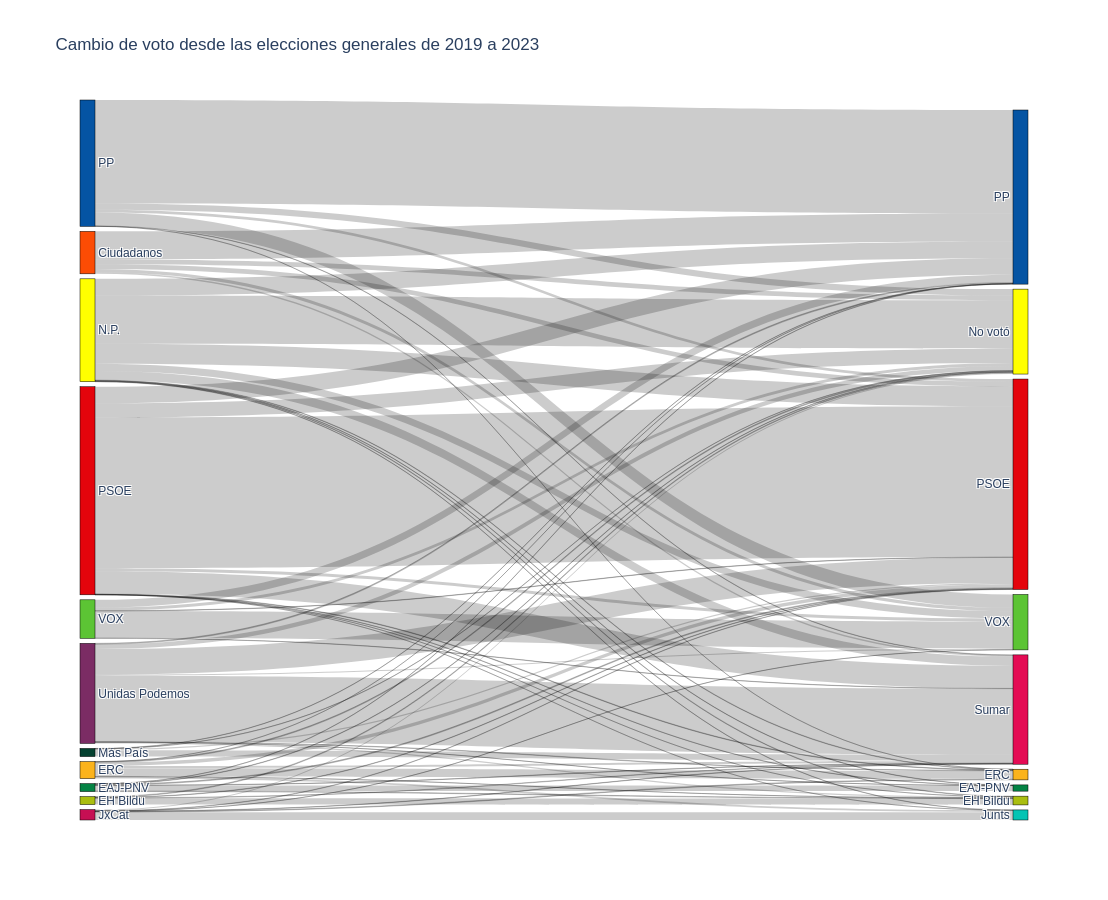

In [11]:
fig = go.Figure(go.Sankey(
    node=dict(
        pad=5,
        thickness=15,
        line=dict(color="black", width=0.5),
        label=etiquetas_completo,
        color=nodo_colores
    ),
    link=dict(
        source=sources,
        target=targets,
        value=valores
    )
))

fig.update_layout(title_text="Cambio de voto desde las elecciones generales de 2019 a 2023", font_size=12, height = 900)

fig.show()

A simple vista podemos ver como en el costado izquierdo, el referente a 2019 hay más partidos que en la parte derecha, la referente a las generales de 2023. Podemos ver como Ciudadanos se diluye (generalmente) en el PP y Más País y Unidas Podemos en Sumar (Unidas Podemos tiene un trasvase de voto notable también en PSOE). Podemos decir que, los partidos nacionalistas, son los que tienen un electorado más fiel, apenas hay cambio de voto entre el 2019 y 2023 entre los encuestados y cuando lo ha habído, ha sido a uno de los partidos grandes (PP o PSOE), solo en ERC vemos cierto flujo hacia Sumar. Es llamativo como muchos votantes del PSOE en 2019 votaron en 2023 a PP o Sumar. Es llamativo como VOX en 2023 coge pequeños encuestados de Ciudadanos y PSOE. Entre los dos grandes vemos como PSOE pierde hacia el PP más que lo que votaron al PP en 2019 van al PSOE.